## To predict the CPU temperature of a laptop based on its continuous power draw (Watts) using purely raw NumPy and Gradient Descent.


### Using data set of AMD Ryzen 7 5800X running under a 240mm AIO liquid cooler.

In [19]:
import numpy as np
from matplotlib import pyplot as plt
plt.style.use("ggplot")
data = np.loadtxt('cpu_telemetry.csv', delimiter=',', skiprows=1)
X_train = data[:, 0]  # All rows, column 0 (Watts)
y_train = data[:, 1] 

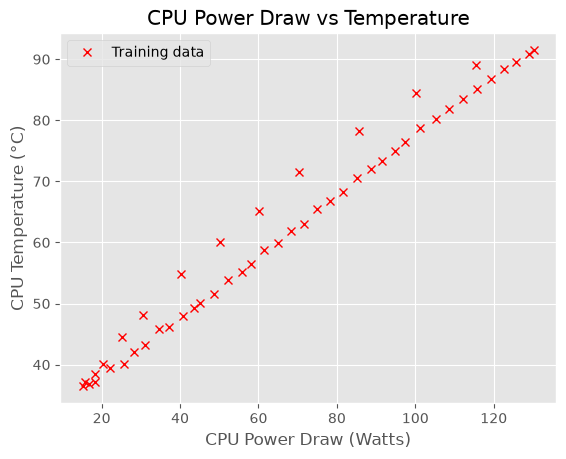

In [20]:
plt.plot(X_train, y_train, 'rx', label='Training data')
plt.xlabel('CPU Power Draw (Watts)')
plt.ylabel('CPU Temperature (°C)')
plt.title('CPU Power Draw vs Temperature')
plt.legend()
plt.show()

In [21]:
w = 0
b = 0
alpha = 0.0001
num_iters = 1000000

### Now defining a function to compute the predicated data using input feature

In [22]:
def compute_yhat(x, w, b):
    """ 
    f(x) = w * x + b
    """
    yhat = (w*x) + b
    return yhat

### Now defining the cost function computation

In [23]:
def compute_cost(x, y, w ,b):
    """
    J(w,b) = (1/2m) * sum((f(x) - y)^2)
    """
    m = y.shape[0]
    yhat = compute_yhat(x, w, b)
    cost = np.sum(np.square((yhat - y )))
    cost = cost / (2*m)
    return cost

Now implementing the gradient descent

In [24]:
def gradient_descent(x,y,w,b,alpha,num_iters):
    """
    w = w - alpha * dj_dw
    b = b - alpha * dj_db
    """
    m = x.shape[0]
    for i in range(num_iters):
        error = ((w*x) + b) -y
        dj_dw = np.dot(error , x)
        dj_db = np.sum(error)
        dj_db = dj_db/m
        dj_dw = dj_dw/m
        w = w - (alpha*dj_dw)
        b = b - (alpha*dj_db)
    return w,b

## Now train the model using gradient descent

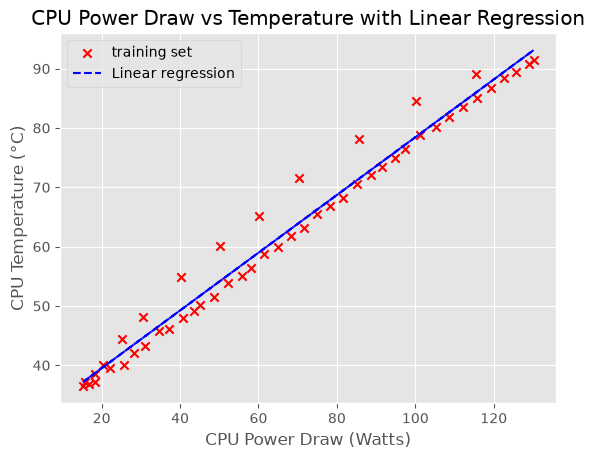

In [ ]:
(w, b) = gradient_descent(X_train, y_train, w, b, alpha, num_iters)
yhat = compute_yhat(X_train, w, b)
plt.scatter(X_train, y_train, marker="x", c='r', label = "Training set")
plt.plot(X_train, yhat, 'b--', label='Linear regression')
plt.xlabel('CPU Power Draw (Watts)')
plt.ylabel('CPU Temperature (°C)')
plt.title('CPU Power Draw vs Temperature with Linear Regression')
plt.legend()
plt.savefig("project0.png")
plt.show()

### Defining function to calculate the the temp of the CPU using the traning set examples.

In [26]:
def predict_temp(watt , w=w , b=b):
    print(f"The temp of the cpu at {watt} Watt: {(w*watt + b):.2f}\N{DEGREE SIGN}C.")


Printing out the predicated temp of CPU.

In [27]:

predict_temp(100)

The temp of the cpu at 100 Watt: 78.44°C.
